# Embedding Techniques Comparison
Compare six embedding methods for candidate ranking by semantic similarity to target keywords.

In [1]:
import subprocess, sys
subprocess.run(
    [sys.executable, "-m", "pip", "install",
     "mittens", "google-generativeai", "datasets",
     "accelerate>=1.1.0", "scikit-learn>=1.5",
     "--upgrade", "transformers", "-q"],
    check=True
)

# Verify transformers version
import importlib
import transformers
importlib.reload(transformers)
print("transformers:", transformers.__version__)

transformers: 5.6.2


In [2]:
import sys
from pathlib import Path

try:
    ROOT = Path(__file__).resolve().parent.parent      # running as script: src/ -> project root
except NameError:
    try:
        ROOT = Path(__vsc_ipynb_file__).resolve().parent.parent  # VS Code notebook: notebooks/ -> project root
    except NameError:
        ROOT = Path().resolve().parent                 # fallback: Jupyter launched from notebooks/

sys.path.insert(0, str(ROOT))

from IPython.display import Image, display
from src.config import DATA_FILE
from src.data_loader import load_data
from src.preprocessing import preprocess
from src.compare_embeddings import METHODS, visualize
from src.visualisation import build_table

df = load_data(ROOT / DATA_FILE)
df = preprocess(df)
df.head()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Job title value counts:
job_title
2019 C.T. Bauer College of Business Graduate (Magna Cum Laude) and aspiring Human Resources professional                 7
Aspiring Human Resources Professional                                                                                    7
Student at Humber College and Aspiring Human Resources Generalist                                                        7
People Development Coordinator at Ryan                                                                                   6
Native English Teacher at EPIK (English Program in Korea)                                                                5
Aspiring Human Resources Specialist                                                                                      5
HR Senior Specialist                                                                                                     5
Student at Chapman University                                                                            

,id,job_title,location,connection,fit,job_title_clean,connections_raw,connections_norm
0,1,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85,NaN,2019 C.T. Bauer College of Business Graduate (...,85,0.170
1,2,Native English Teacher at EPIK (English Progra...,Kanada,500+,NaN,Native English Teacher at EPIK (English Progra...,500,1.000
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN,Aspiring Human Resources Professional,44,0.088
3,4,People Development Coordinator at Ryan,"Denton, Texas",500+,NaN,People Development Coordinator at Ryan,500,1.000
4,5,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",500+,NaN,Advisory Board Member at Celal Bayar University,500,1.000


## Inspect raw data

In [3]:
print(df.shape)
print(df.dtypes)
df["connection"].value_counts()

(104, 8)
id                    int64
job_title            object
location             object
connection           object
fit                 float64
job_title_clean      object
connections_raw       int64
connections_norm    float64
dtype: object


connection
500+     44
85        7
61        7
44        6
1         5
2         4
4         2
7         2
57        2
390       2
103       1
48        1
18        1
71        1
19        1
415       1
9         1
64        1
39        1
155       1
349       1
174       1
40        1
50        1
268       1
455       1
52        1
409       1
212       1
16        1
5         1
82        1
49        1
Name: count, dtype: int64

## Preprocess

Three steps:
1. `job_title_clean` - title kept as-is (transformer models handle raw text better than stripped tokens)
2. `connections_raw` - parse "500+" → 500, invalid → 0
3. `connections_norm` - divide by 500, clip to [0, 1] so it can be blended with cosine similarity scores

> **Note on abbreviations:** During preprocessing, all-uppercase abbreviations found in the dataset (e.g. `HR`, `HRIS`, `MBA`) are printed for visibility. They are **not expanded or normalised** — the job titles are passed to the models as-is. Transformer-based and LLM models are pre-trained on large corpora that include these abbreviations, so they are expected to handle them correctly without manual expansion.

In [4]:
df[["job_title", "job_title_clean", "connections_raw", "connections_norm"]].head(10)

,job_title,job_title_clean,connections_raw,connections_norm
0,2019 C.T. Bauer College of Business Graduate (...,2019 C.T. Bauer College of Business Graduate (...,85,0.170
1,Native English Teacher at EPIK (English Progra...,Native English Teacher at EPIK (English Progra...,500,1.000
2,Aspiring Human Resources Professional,Aspiring Human Resources Professional,44,0.088
3,People Development Coordinator at Ryan,People Development Coordinator at Ryan,500,1.000
4,Advisory Board Member at Celal Bayar University,Advisory Board Member at Celal Bayar University,500,1.000
5,Aspiring Human Resources Specialist,Aspiring Human Resources Specialist,1,0.002
6,Student at Humber College and Aspiring Human R...,Student at Humber College and Aspiring Human R...,61,0.122
7,HR Senior Specialist,HR Senior Specialist,500,1.000
8,Student at Humber College and Aspiring Human R...,Student at Humber College and Aspiring Human R...,61,0.122
9,Seeking Human Resources HRIS and Generalist Po...,Seeking Human Resources HRIS and Generalist Po...,500,1.000


## Embedding Methods Overview

Each method embeds candidate job titles and target keywords into vector space,
then computes cosine similarity. The candidate's score = max similarity across all targets.

| Method       | Type               | Trained on                                   | Key property |
|--------------|--------------------|--------------------------------------------- |--------------|
| TF-IDF       | Bag-of-words       | This corpus                                  | Exact word match, weighted by rarity |
| Word2Vec     | Word embeddings    | This corpus                                  | Context-based, avg pooling |
| FastText     | Subword embeddings | This corpus                                  | Handles rare/misspelled words |
| GloVe-FT     | Word embeddings    | Wikipedia + Gigaword → fine-tuned (Mittens)  | Pretrained vectors adapted to job-title vocab |
| BERT-FT      | Transformer        | Large pretraining → fine-tuned (SimCSE)      | Full sentence context, domain-adapted |
| E5-small-FT  | Transformer        | Large pretraining → fine-tuned (SimCSE)      | Retrieval-optimized, asymmetric query/passage |

## TF-IDF

**What it is:** Bag-of-words method. Gives each word a weight based on how often it appears
in a document (TF) and how rare it is across all documents (IDF). No understanding of meaning.

**Advantage:** Simple, fast, interpretable.

**Disadvantages:**
- Long titles get penalized: "Aspiring HR Manager | Graduating May 2020 | Seeking Entry-Level Position"
  has its signal diluted by extra words, so cosine similarity with the short target is lower
  even though the candidate is clearly relevant.
- Vocabulary mismatch: "HR" and "Human Resources" are treated as completely unrelated.
  "seek" and "seeking" are different tokens even after lemmatization.

In [5]:
df["fit_tfidf"] = METHODS["TF-IDF"](df)
df[["id", "job_title", "fit_tfidf"]].sort_values("fit_tfidf", ascending=False).head(10)

[TF-IDF]    vocab size: 200 words  →  each title is a 200-dim vector  |  parameters: 200 IDF weights


,id,job_title,fit_tfidf
32,33,Aspiring Human Resources Professional,0.749144
96,97,Aspiring Human Resources Professional,0.749144
20,21,Aspiring Human Resources Professional,0.749144
45,46,Aspiring Human Resources Professional,0.749144
57,58,Aspiring Human Resources Professional,0.749144
16,17,Aspiring Human Resources Professional,0.749144
2,3,Aspiring Human Resources Professional,0.749144
5,6,Aspiring Human Resources Specialist,0.691187
35,36,Aspiring Human Resources Specialist,0.691187
48,49,Aspiring Human Resources Specialist,0.691187


## Word2Vec

**What it is:** Trains a shallow neural network to predict surrounding words (skip-gram)
or the current word from context (CBOW). Words appearing in similar contexts get similar vectors.
A candidate's title vector = average of its word vectors.

**Advantage over TF-IDF:** Words don't need to match exactly.
"HR" and "human resources" may end up nearby if they appear in similar contexts.

**Disadvantages:**
- **Negation failure:** Averaging ignores negation.
  "not interested in management" and "interested in management" produce nearly the same vector
  because "not" is a tiny, direction-agnostic word that barely shifts the mean.
- **Small corpus:** With only ~100 job titles, Word2Vec can't learn reliable relationships.
  "aspiring" and "seeking" will have near-random vectors relative to each other.
- **Averaging loses word order:** "Human Resources Manager" and "Manager Human Resources"
  produce identical vectors.

In [6]:
df["fit_w2v"] = METHODS["Word2Vec"](df)
df[["id", "job_title", "fit_w2v"]].sort_values("fit_w2v", ascending=False).head(10)

c:\Users\D01173\AppData\Local\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "cipher": algorithms.TripleDES,
c:\Users\D01173\AppData\Local\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "class": algorithms.TripleDES,


[Word2Vec]  vocab size: 223 words  ×  100 dims  ×  2 matrices  |  parameters: 44,600


,id,job_title,fit_w2v
69,70,"Retired Army National Guard Recruiter, office ...",0.998939
91,92,Seeking employment opportunities within Custom...,0.998447
102,103,Always set them up for Success,0.998405
79,80,Junior MES Engineer| Information Systems,0.998097
84,85,RRP Brand Portfolio Executive at JTI (Japan To...,0.998055
74,75,"Nortia Staffing is seeking Human Resources, Pa...",0.997988
92,93,Admissions Representative at Community medical...,0.997960
89,90,Undergraduate Research Assistant at Styczynski...,0.997701
82,83,HR Manager at Endemol Shine North America,0.997577
85,86,Information Systems Specialist and Programmer ...,0.997571


## FastText

**What it is:** Extends Word2Vec with character-level n-gram embeddings.
"resources" → "res", "reso", "resou", ... The word vector = average of all its n-gram vectors.

**Advantage over Word2Vec:** Handles rare and unseen words.
"HR-Specialist" or "Resourcing" can still get a meaningful vector by composing
subword pieces shared with known words like "resource" and "resources".

**Disadvantages:**
- Still trained on a small corpus (~100 titles) — n-gram patterns are poorly calibrated.
- Averaging still loses word order, same as Word2Vec.
- **Cannot distinguish intent from surface similarity:**
  "looking for HR manager role" (candidate) and "hiring HR manager role" (employer)
  share the same words → nearly identical vectors. FastText has no way to tell them apart.
  BERT-style models handle this better by encoding full sentence context.

In [7]:
df["fit_ft"] = METHODS["FastText"](df)
df[["id", "job_title", "fit_ft"]].sort_values("fit_ft", ascending=False).head(10)

[FastText]  vocab size: 223 words  +  2000000 n-gram buckets  ×  100 dims  ×  2 matrices  |  parameters: 400,044,600


,id,job_title,fit_ft
32,33,Aspiring Human Resources Professional,0.999964
45,46,Aspiring Human Resources Professional,0.999964
96,97,Aspiring Human Resources Professional,0.999964
20,21,Aspiring Human Resources Professional,0.999964
16,17,Aspiring Human Resources Professional,0.999964
57,58,Aspiring Human Resources Professional,0.999964
2,3,Aspiring Human Resources Professional,0.999964
28,29,Aspiring Human Resources Management student se...,0.999961
26,27,Aspiring Human Resources Management student se...,0.999961
29,30,Seeking Human Resources Opportunities,0.999954


## GloVe

**What it is:** Pretrained word embeddings trained on 6 billion tokens from Wikipedia
and Gigaword by factorizing a global word co-occurrence matrix.

**Advantage over Word2Vec/FastText on our corpus:** Trained on massive, diverse data —
"aspiring", "seeking", "human", "resources" all have well-calibrated vectors.
"HR" and "human resources" are likely close because they co-occur in the same Wikipedia contexts.

**Disadvantages:**
- **Domain gap:** Not trained on job postings or LinkedIn data.
  Jargon like "HRBP" or "talent acquisition" may be absent (OOV → zero vector).
- **Still word-level averaging:** Same word-order and negation blindness as Word2Vec.

In [8]:
df["fit_glove"] = METHODS["GloVe-FT"](df)
df[["id", "job_title", "fit_glove"]].sort_values("fit_glove", ascending=False).head(10)

Iteration 1000: error 1.1363

,id,job_title,fit_glove
75,76,Aspiring Human Resources Professional | Passio...,0.769021
74,75,"Nortia Staffing is seeking Human Resources, Pa...",0.766379
65,66,Experienced Retail Manager and aspiring Human ...,0.751334
91,92,Seeking employment opportunities within Custom...,0.736802
85,86,Information Systems Specialist and Programmer ...,0.720416
0,1,2019 C.T. Bauer College of Business Graduate (...,0.713381
43,44,2019 C.T. Bauer College of Business Graduate (...,0.713381
56,57,2019 C.T. Bauer College of Business Graduate (...,0.713381
14,15,2019 C.T. Bauer College of Business Graduate (...,0.713381
13,14,2019 C.T. Bauer College of Business Graduate (...,0.713381


## BERT (all-MiniLM-L6-v2)

**What it is:** Transformer model that encodes the entire sentence at once using self-attention.
Every token attends to every other token, so context is captured — "resources" in
"human resources" is represented differently than "resources" in "natural resources".

**Advantages:**
- Semantic understanding: matches "aspiring human resources" with "HR enthusiast looking for a role"
  even with no word overlap.
- Handles long titles: the full title is encoded as one vector — extra words don't dilute the signal.
- No preprocessing needed: handles punctuation, casing, and stopwords internally.

**Disadvantage — symmetric model:**
all-MiniLM-L6-v2 encodes both the candidate title and the target keyword the same way.
It does not distinguish between a "document to be retrieved" and a "search query".
For asymmetric retrieval (short query vs. longer document), E5 is better suited.

In [9]:
df["fit_bert"] = METHODS["BERT-FT"](df)
df[["id", "job_title", "fit_bert"]].sort_values("fit_bert", ascending=False).head(10)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

c:\Users\D01173\AppData\Local\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'train_runtime': '12.23', 'train_samples_per_second': '43.35', 'train_steps_per_second': '2.862', 'train_loss': '0.3081', 'epoch': '5'}


,id,job_title,fit_bert
16,17,Aspiring Human Resources Professional,0.949336
2,3,Aspiring Human Resources Professional,0.949336
45,46,Aspiring Human Resources Professional,0.949336
57,58,Aspiring Human Resources Professional,0.949336
96,97,Aspiring Human Resources Professional,0.949336
32,33,Aspiring Human Resources Professional,0.949336
20,21,Aspiring Human Resources Professional,0.949336
48,49,Aspiring Human Resources Specialist,0.927270
23,24,Aspiring Human Resources Specialist,0.927270
5,6,Aspiring Human Resources Specialist,0.927270


## E5-small (intfloat/e5-small-v2)

**What it is:** Transformer model designed specifically for text retrieval.
Trained to distinguish between **queries** (what you search for) and **passages** (documents being searched).
The "passage: " and "query: " prefixes are mandatory — they are part of the model's training protocol.
Omitting them produces generic embeddings and significantly degrades similarity scores.

**How it differs from BERT:**
- BERT is **symmetric**: both sides encoded the same way.
- E5 is **asymmetric**: query and passage have separate learned representations,
  which better matches real retrieval — a short keyword and a long job title are different in nature.

**Advantages:**
- Purpose-built for retrieval: "query: aspiring human resources" pulls close to
  "passage: Aspiring HR Professional | Entry-Level Candidate" even without exact word overlap.
- Strong out-of-the-box performance — no fine-tuning needed on our data.

**Disadvantage:** e5-small-v2 is a compressed model (12M parameters).
e5-large-v2 would be more accurate but slower — for ~100 candidates the small variant is sufficient.

In [10]:
df["fit_e5"] = METHODS["E5-small-FT"](df)
df[["id", "job_title", "fit_e5"]].sort_values("fit_e5", ascending=False).head(10)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

c:\Users\D01173\AppData\Local\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'train_runtime': '21.91', 'train_samples_per_second': '24.19', 'train_steps_per_second': '1.598', 'train_loss': '0.7518', 'epoch': '5'}


,id,job_title,fit_e5
27,28,Seeking Human Resources Opportunities,0.944741
29,30,Seeking Human Resources Opportunities,0.944741
98,99,Seeking Human Resources Position,0.943490
45,46,Aspiring Human Resources Professional,0.930092
20,21,Aspiring Human Resources Professional,0.930092
32,33,Aspiring Human Resources Professional,0.930092
57,58,Aspiring Human Resources Professional,0.930092
16,17,Aspiring Human Resources Professional,0.930092
96,97,Aspiring Human Resources Professional,0.930092
2,3,Aspiring Human Resources Professional,0.930092


## Score Comparison Across All Methods

In [11]:
score_cols = ["id", "job_title", "fit_tfidf", "fit_w2v", "fit_ft", "fit_glove", "fit_bert", "fit_e5"]
df[score_cols].sort_values("fit_e5", ascending=False).head(20)

,id,job_title,fit_tfidf,fit_w2v,fit_ft,fit_glove,fit_bert,fit_e5
27,28,Seeking Human Resources Opportunities,0.658595,0.993903,0.999954,0.000000,0.898674,0.944741
29,30,Seeking Human Resources Opportunities,0.658595,0.993903,0.999954,0.000000,0.898674,0.944741
98,99,Seeking Human Resources Position,0.638511,0.993051,0.999948,0.000000,0.903607,0.943490
45,46,Aspiring Human Resources Professional,0.749144,0.993827,0.999964,0.000000,0.949336,0.930092
20,21,Aspiring Human Resources Professional,0.749144,0.993827,0.999964,0.000000,0.949336,0.930092
32,33,Aspiring Human Resources Professional,0.749144,0.993827,0.999964,0.000000,0.949336,0.930092
57,58,Aspiring Human Resources Professional,0.749144,0.993827,0.999964,0.000000,0.949336,0.930092
16,17,Aspiring Human Resources Professional,0.749144,0.993827,0.999964,0.000000,0.949336,0.930092
96,97,Aspiring Human Resources Professional,0.749144,0.993827,0.999964,0.000000,0.949336,0.930092
2,3,Aspiring Human Resources Professional,0.749144,0.993827,0.999964,0.000000,0.949336,0.930092


## Visualize Embedding Space

Each method's embeddings are reduced to 2D using PCA and t-SNE.
- **Green dots** = candidates starred by the recruiter (relevant)
- **Light blue dots** = non-relevant candidates
- **Red stars** = target keywords (T1, T2)

A good embedding method should cluster green dots close to the red stars.

In [12]:
visualize(df)

Computing embeddings for visualization...
  TF-IDF... done
  Word2Vec... done
  FastText... done
  GloVe-FT... 

Iteration 1000: error 1.1506

done
  BERT-FT... 

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

...

{'train_runtime': '11.5', 'train_samples_per_second': '46.08', 'train_steps_per_second': '3.043', 'train_loss': '0.2655', 'epoch': '5'}
done
  E5-small-FT... 

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

c:\Users\D01173\AppData\Local\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'train_runtime': '21.02', 'train_samples_per_second': '25.22', 'train_steps_per_second': '1.665', 'train_loss': '0.7455', 'epoch': '5'}
done

Reducing with PCA...
Saved: C:\Users\D01173\Downloads\workspace\talent-ranking-llm\outputs\embedding_space_pca.png
Reducing with t-SNE (slower)...
Saved: C:\Users\D01173\Downloads\workspace\talent-ranking-llm\outputs\embedding_space_tsne.png


### PCA — Linear projection (fast, shows global structure)

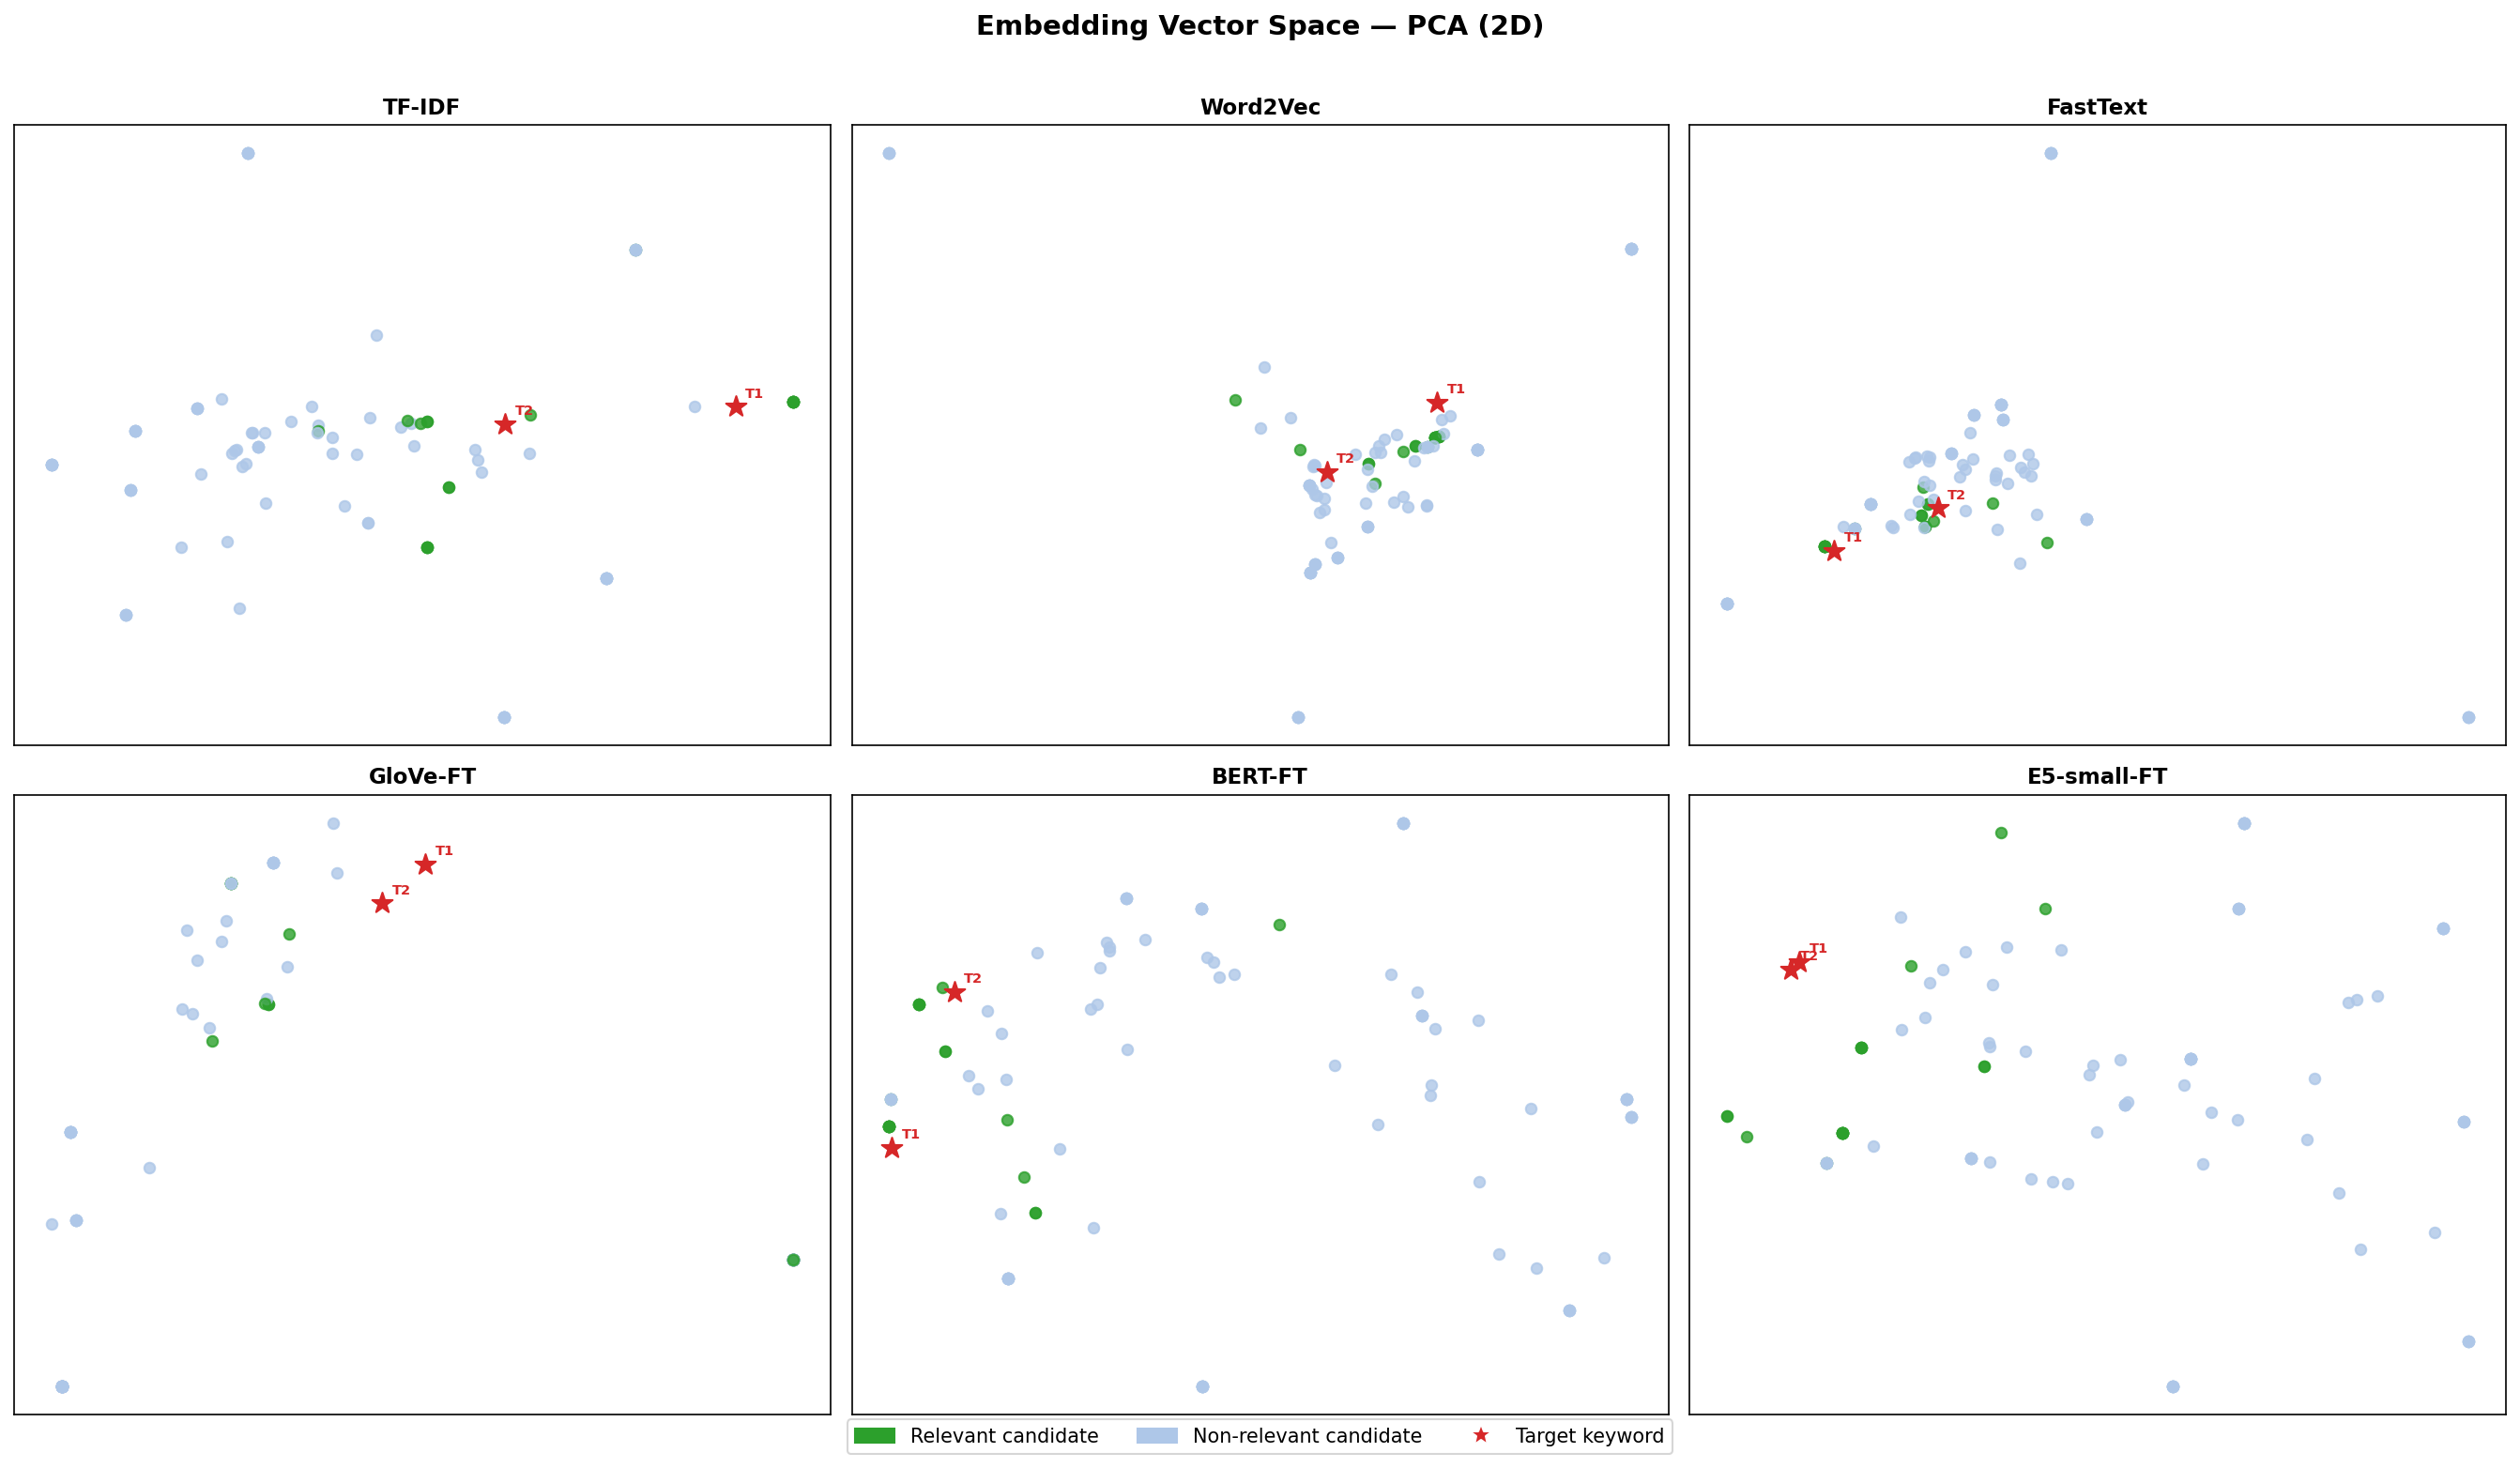

In [13]:
display(Image(filename=str(ROOT / "outputs" / "embedding_space_pca.png")))

### t-SNE — Non-linear projection (slower, better cluster separation)

Note: distances *between* clusters in t-SNE are not meaningful — only local neighbourhood structure is.

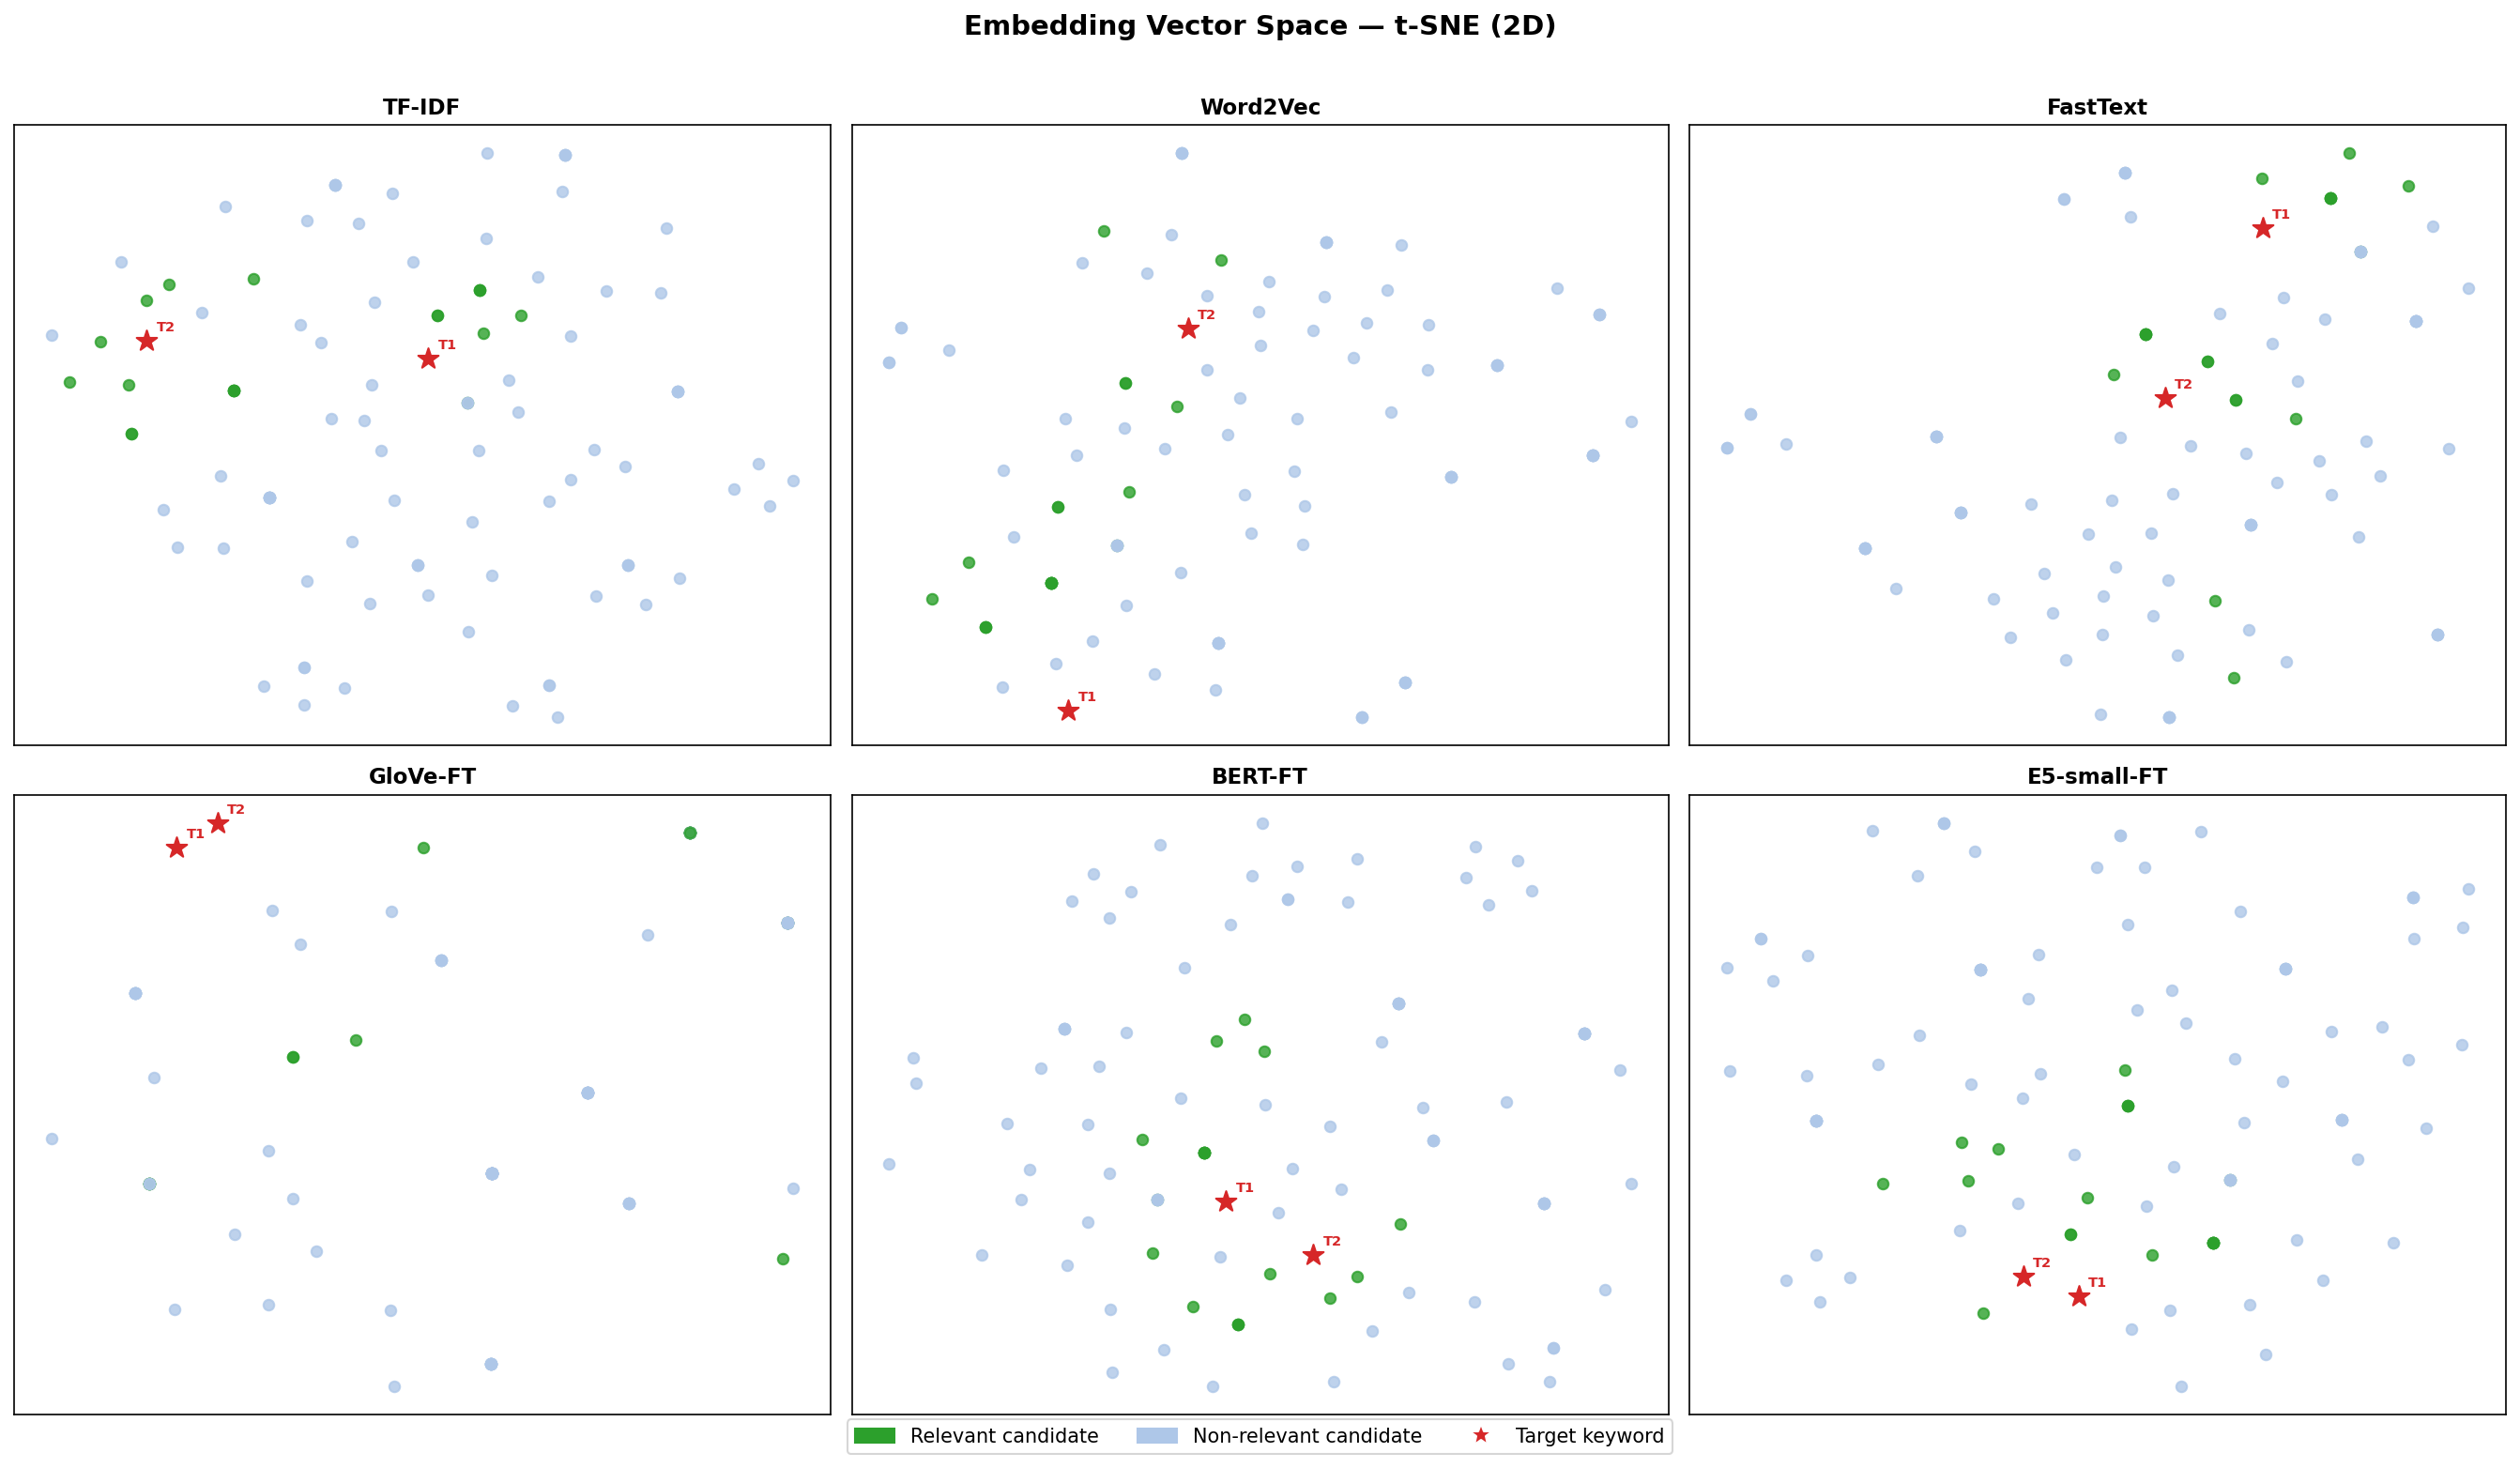

In [14]:
display(Image(filename=str(ROOT / "outputs" / "embedding_space_tsne.png")))

## Candidate Comparison Table

Top-10 candidate IDs selected by each method — 18 columns total.

**Embedding methods (6):** ranked by similarity score blended with `connections_norm` (w=0.7).

| Column | Method |
|--------|--------|
| TF-IDF | Bag-of-words similarity |
| Word2Vec | Corpus-trained word embeddings |
| FastText | Subword embeddings |
| GloVe-FT | Pretrained GloVe + fine-tuned |
| BERT-FT | Transformer sentence embeddings |
| E5-small-FT | Retrieval-optimised transformer |

**LLM methods (12):** top-10 from 4 prompting techniques × 3 models.

| Model | Type | Size |
|-------|------|------|
| Qwen2.5-1.5B-Instruct | Local HF model | 1.5B params |
| Gemma-4-E2B-it | Local HF model | 2B params |
| Llama-3.1-8B | Cerebras free API | 8B params |

| Technique | Description |
|-----------|-------------|
| Zero-shot | Plain instruction, no examples |
| Few-shot | Small worked example shown before the question |
| Chat | Framed as a user ↔ assistant conversation |
| CoT | Model reasons step-by-step before answering |

In [15]:
tbl = build_table(df)
tbl

[TF-IDF]    vocab size: 200 words  →  each title is a 200-dim vector  |  parameters: 200 IDF weights
[Word2Vec]  vocab size: 223 words  ×  100 dims  ×  2 matrices  |  parameters: 44,600
[FastText]  vocab size: 223 words  +  2000000 n-gram buckets  ×  100 dims  ×  2 matrices  |  parameters: 400,044,600


Iteration 1000: error 1.1532

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

c:\Users\D01173\AppData\Local\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


...


─ Zero-shot ─
  30, 34, 38, 40, 42, 44, 46, 48, 50, 52

─ Few-shot ─
  100, 99, 85, 75, 74, 73, 72, 71, 66, 65

─ Chat ─
  Based on the provided list, here are the top 10 most relevant job titles for a Human Resources position:

1. 2019 C.T. B

─ CoT ─
  1, 10, 11, 12, 13, 14, 15, 16, 17, 18
  Qwen unloaded.

Loading Gemma (google/gemma-4-E2B-it) locally …
Loading google/gemma-4-E2B-it …


Loading weights:   0%|          | 0/1951 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



─ Zero-shot ─
  1, 3, 6, 7, 9, 10, 13, 14, 15, 17

─ Few-shot ─
  12, 89, 69, 81, 67, 71, 78, 83, 9, 2, 14

─ Chat ─
  Here are the top 10 most relevant job titles/descriptions for a Human Resources position, ranked from most relevant to l

─ CoT ─
  Here is the analysis based on your request:

**Step 1 — What keywords indicate an HR-aspiring candidate (e.g. 'human res
  Gemma unloaded.

Calling Cerebras API (llama3.1-8b) …

─ Zero-shot ─
  1, 2, 4, 6, 7, 9, 10, 11, 41, 54

─ Few-shot ─
  1, 42, 82, 91, 89, 71, 78, 103, 77, 81

─ Chat ─
  Based on the list, here are the top 10 most relevant job titles for a human resources position, in ranked order:

1. 82.

─ CoT ─
  Step 1 — The keywords that indicate an HR-aspiring candidate are:
- 'human resources'
- 'HR'
- 'aspiring'
- 'seeking'

S


,TF-IDF,Word2Vec,FastText,GloVe-FT,BERT-FT,E5-small-FT,Qwen-Zero-shot,Qwen-Few-shot,Qwen-Chat,Qwen-CoT,Gemma-Zero-shot,Gemma-Few-shot,Gemma-Chat,Gemma-CoT,Llama-Zero-shot,Llama-Few-shot,Llama-Chat,Llama-CoT
Rank,,,,,,,,,,,,,,,,,,
1,30,103,29,75,53,53,30,100,10.0,1,1,12,10.0,1,1,1,10.0,1
2,28,85,27,53,10,10,34,99,1.0,10,3,89,1.0,2,2,42,1.0,2
3,53,75,40,40,62,40,38,85,2.0,11,6,69,9.0,104,4,82,82.0,1
4,10,104,62,10,40,62,40,75,3.0,12,7,81,2.0,3,6,91,2.0,1
5,62,29,53,67,30,29,42,74,4.0,13,9,67,67.0,10,7,89,81.0,2
6,40,27,10,62,28,27,44,73,5.0,14,10,71,3.0,1,9,71,81.0,3
7,29,69,67,103,67,67,46,72,NaN,15,13,78,68.0,10,10,78,81.0,3
8,27,26,69,29,27,75,48,71,NaN,16,14,83,4.0,2,11,103,81.0,4
9,97,8,71,27,29,28,50,66,NaN,17,15,9,NaN,28,41,77,NaN,4
